<a href="https://colab.research.google.com/github/bhar-gav/machine_learning/blob/main/activation_func_dl_a2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bhargav  -- 21DCS022**



---


1.   Activation Functions





In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10, cifar100
from tensorflow.keras.utils import to_categorical


def sigmoid(x):
    return tf.nn.sigmoid(x)

def bipolar_sigmoid(x):
    return 2 * tf.nn.sigmoid(x) - 1

def tanh(x):
    return tf.nn.tanh(x)

def mish(x):
    return x * tf.nn.tanh(tf.nn.softplus(x))

def telu(x):
    return x * tf.nn.softplus(x)

def relu(x):
    return tf.nn.relu(x)

def leaky_relu(x, alpha=0.01):
    return tf.nn.leaky_relu(x, alpha=alpha)

def prelu(x, alpha=0.01):
    return tf.keras.layers.PReLU()(x)

def elu(x, alpha=1.0):
    return tf.nn.elu(x)

def softmax(x):
    return tf.nn.softmax(x)

def softplus(x):
    return tf.nn.softplus(x)

def swish(x):
    return x * tf.nn.sigmoid(x)

def eswish(x):
    return x * tf.nn.sigmoid(x)

def gelu(x):
    return tf.nn.gelu(x)

def selu(x):
    return tf.nn.selu(x)




---
**Datasets**

In [2]:

def load_data(dataset_name):
    if dataset_name == "MNIST":
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train = np.expand_dims(x_train, -1).astype("float32") / 255.0
        x_test = np.expand_dims(x_test, -1).astype("float32") / 255.0
    elif dataset_name == "Fashion-MNIST":
        (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
        x_train = np.expand_dims(x_train, -1).astype("float32") / 255.0
        x_test = np.expand_dims(x_test, -1).astype("float32") / 255.0
    elif dataset_name == "CIFAR-10":
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()
        x_train = x_train.astype("float32") / 255.0
        x_test = x_test.astype("float32") / 255.0
    elif dataset_name == "CIFAR-100":
        (x_train, y_train), (x_test, y_test) = cifar100.load_data()
        x_train = x_train.astype("float32") / 255.0
        x_test = x_test.astype("float32") / 255.0
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)
    return x_train, y_train, x_test, y_test


# Train Model Function
def train_model(model, x_train, y_train, x_test, y_test, activation_fn):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))
    return history


def plot_history(history, activation_fn_name, dataset_name, model_name):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - {activation_fn_name} on {dataset_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()





---
**architectures ResNet, LeNet, MobileNet, AlexNet**

In [3]:

# LeNet Architecture
def lenet_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(6, (5, 5), activation='relu', input_shape=input_shape),
        layers.AvgPool2D(pool_size=(2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AvgPool2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


# Simple ResNet Architecture
def resnet_model(input_shape, num_classes):
    model = models.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


def alexnet_model(input_shape, num_classes):
    model = models.Sequential([
        # Adjusted first Conv2D layer with smaller kernel and stride
        layers.Conv2D(96, (3, 3), strides=(1, 1), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        layers.Conv2D(384, (3, 3), activation='relu'),
        layers.Conv2D(384, (3, 3), activation='relu'),
        layers.Conv2D(256, (3, 3), activation='relu'),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(4096, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model






---
TRAIN


938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.6746 - loss: 2.1059 - val_accuracy: 0.8579 - val_loss: 2.0224
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8603 - loss: 2.0213 - val_accuracy: 0.8694 - val_loss: 2.0176
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.8768 - loss: 2.0149 - val_accuracy: 0.8703 - val_loss: 2.0177
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8798 - loss: 2.0137 - val_accuracy: 0.8814 - val_loss: 2.0128
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.8838 - loss: 2.0123 - val_accuracy: 0.8824 - val_loss: 2.0126
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.8964 - loss: 2.0074 - val_accuracy: 0.9724 - val_loss: 1.9787
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9782 - loss: 1.9762 - val_accuracy: 0.9795 - val_loss: 1.9757
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9822 - loss: 1.9747 - val_accurac

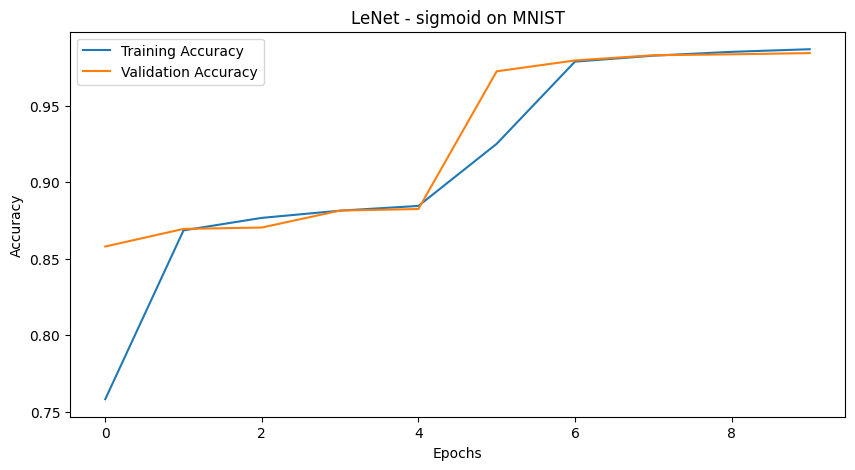

Finished training LeNet with sigmoid
Training LeNet with relu activation
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.8119 - loss: 0.6478 - val_accuracy: 0.9722 - val_loss: 0.0896
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9684 - loss: 0.0987 - val_accuracy: 0.9797 - val_loss: 0.0599
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9800 - loss: 0.0644 - val_accuracy: 0.9839 - val_loss: 0.0475
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.9846 - loss: 0.0498 - val_accuracy: 0.9873 - val_loss: 0.0415
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.9875 - loss: 0.0389 - val_accuracy: 0.9865 - val_loss: 0.0379
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy: 0.9893 - loss: 0.0335 - val_accuracy: 0.9903 - val_loss: 0.0322
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9915 - loss: 0.0256 - val_accuracy: 0.9874 - val_loss: 0.0394
Epoch 8/10
938/93

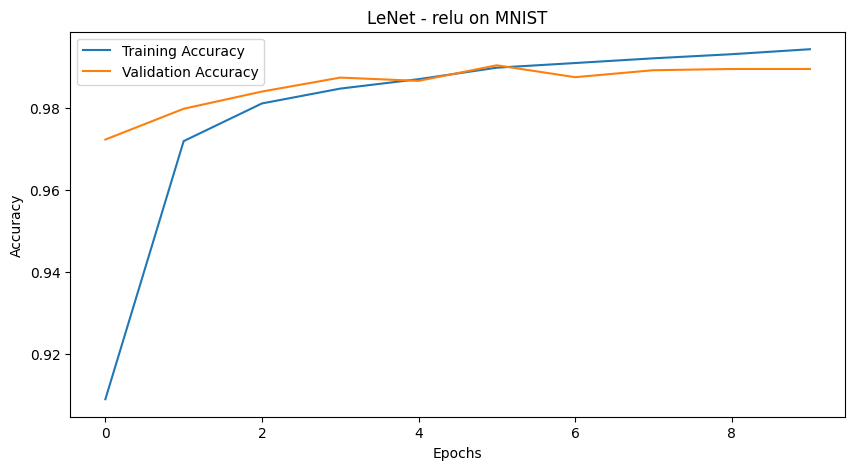

Finished training LeNet with relu
Training LeNet with leaky_relu activation
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8217 - loss: 0.6153 - val_accuracy: 0.9712 - val_loss: 0.0941
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9682 - loss: 0.1052 - val_accuracy: 0.9791 - val_loss: 0.0656
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9780 - loss: 0.0706 - val_accuracy: 0.9826 - val_loss: 0.0589
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.9815 - loss: 0.0586 - val_accuracy: 0.9861 - val_loss: 0.0449
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9855 - loss: 0.0452 - val_accuracy: 0.9855 - val_loss: 0.0487
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.9884 - loss: 0.0379 - val_accuracy: 0.9871 - val_loss: 0.0417
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9896 - loss: 0.0328 - val_accuracy: 0.9862 - val_loss: 0.0451
Epoch 8/10
938

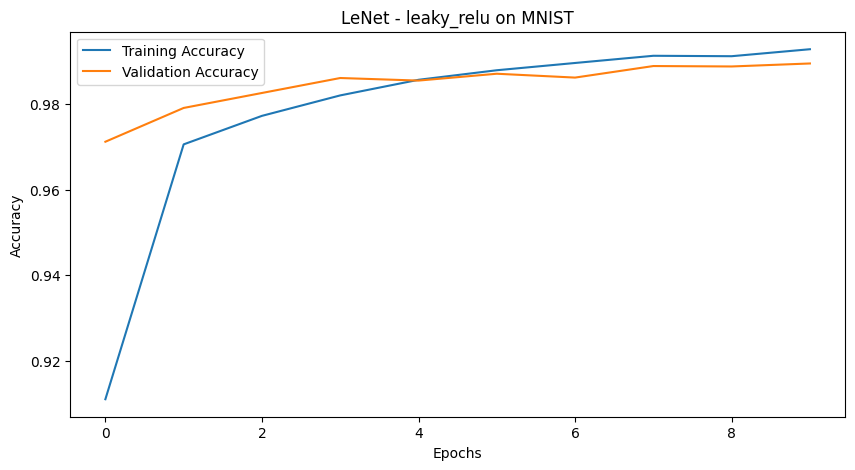

Finished training LeNet with leaky_relu
Training LeNet with tanh activation
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8429 - loss: 0.5557 - val_accuracy: 0.9737 - val_loss: 0.0821
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9697 - loss: 0.0972 - val_accuracy: 0.9803 - val_loss: 0.0584
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9803 - loss: 0.0642 - val_accuracy: 0.9874 - val_loss: 0.0412
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9850 - loss: 0.0469 - val_accuracy: 0.9847 - val_loss: 0.0457
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9879 - loss: 0.0396 - val_accuracy: 0.9852 - val_loss: 0.0456
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9824 - val_loss: 0.0524
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9916 - loss: 0.0266 - val_accuracy: 0.9889 - val_loss: 0.0345
Epoch 8/10
938

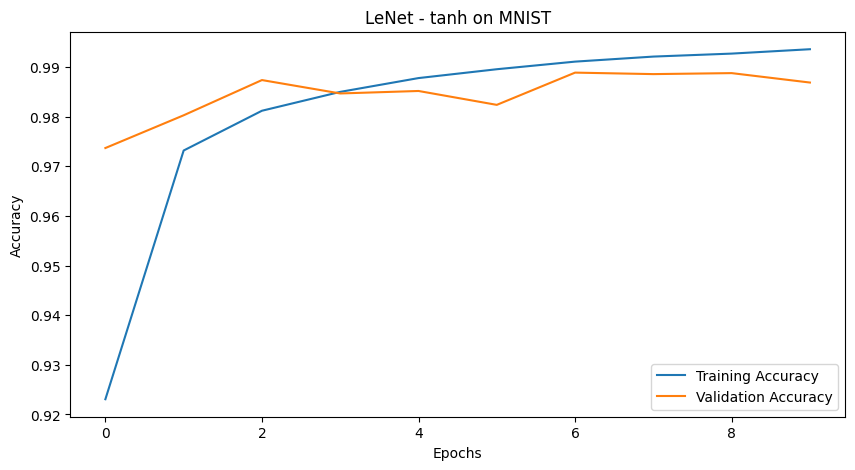

Finished training LeNet with tanh
Training LeNet with softmax activation
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.7399 - loss: 1.7437 - val_accuracy: 0.9269 - val_loss: 1.5375
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9423 - loss: 1.5208 - val_accuracy: 0.9658 - val_loss: 1.4961
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9638 - loss: 1.4994 - val_accuracy: 0.9732 - val_loss: 1.4890
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9707 - loss: 1.4910 - val_accuracy: 0.9699 - val_loss: 1.4910
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9739 - loss: 1.4875 - val_accuracy: 0.9744 - val_loss: 1.4864
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9785 - loss: 1.4830 - val_accuracy: 0.9752 - val_loss: 1.4862
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9809 - loss: 1.4808 - val_accuracy: 0.9792 - val_loss: 1.4826
Epoch 8/10
938/93

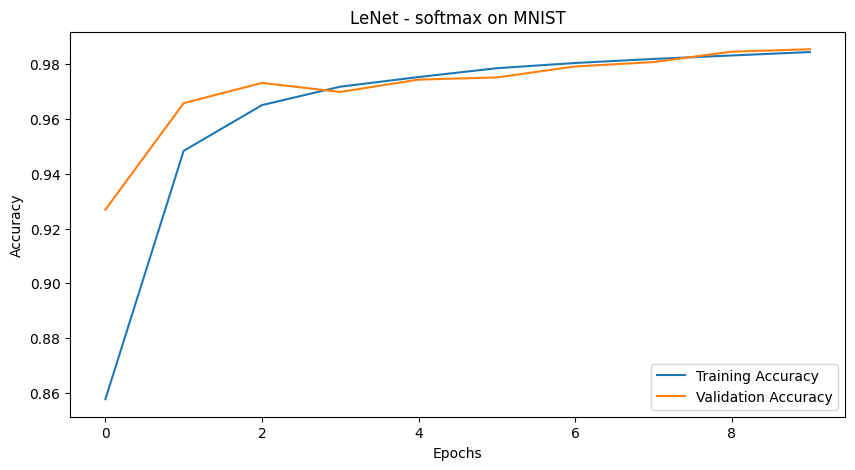

Finished training LeNet with softmax
Training LeNet with gelu activation
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.8137 - loss: 0.6044 - val_accuracy: 0.9659 - val_loss: 0.1068
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9683 - loss: 0.1048 - val_accuracy: 0.9763 - val_loss: 0.0748
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9770 - loss: 0.0760 - val_accuracy: 0.9845 - val_loss: 0.0516
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9830 - loss: 0.0551 - val_accuracy: 0.9852 - val_loss: 0.0442
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9879 - val_loss: 0.0383
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9887 - loss: 0.0362 - val_accuracy: 0.9859 - val_loss: 0.0433
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9897 - loss: 0.0316 - val_accuracy: 0.9881 - val_loss: 0.0342
Epoch 8/10
938/93

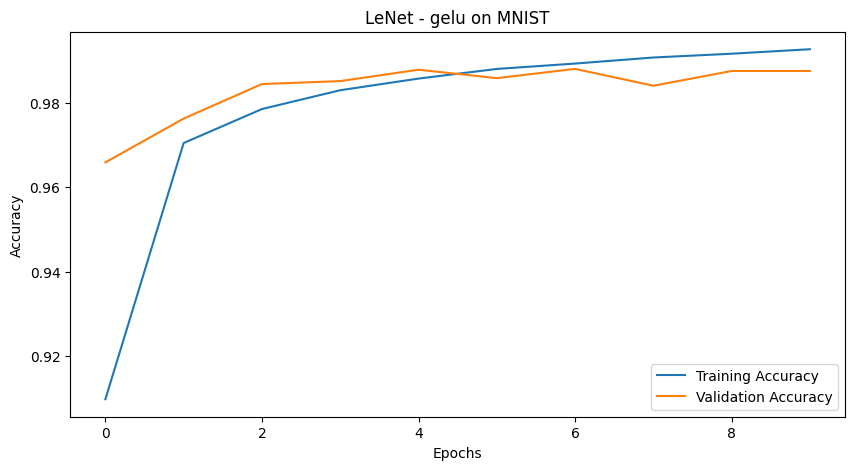

Finished training LeNet with gelu


In [6]:

datasets = ['MNIST']# 'Fashion-MNIST', 'CIFAR-10', 'CIFAR-100']

activation_functions = [sigmoid, relu, leaky_relu, tanh, softmax, gelu] # mish, swish, prelu, elu, eswish, selu

models_dict = {
    'LeNet': lenet_model,
    # 'ResNet': resnet_model,
    # 'AlexNet': alexnet_model
}


for dataset in datasets:
    print(f"Training on {dataset} dataset")
    x_train, y_train, x_test, y_test = load_data(dataset)

    for model_name, model_fn in models_dict.items():
        for activation_fn in activation_functions:
            print(f"Training {model_name} with {activation_fn.__name__} activation")

            model = model_fn(input_shape=x_train.shape[1:], num_classes=y_train.shape[1])

            # Apply activation function via Lambda layer
            model.add(layers.Lambda(activation_fn))

            # Train model
            history = train_model(model, x_train, y_train, x_test, y_test, activation_fn)

            plot_history(history, activation_fn.__name__, dataset, model_name)

            del model
            tf.keras.backend.clear_session()

            print(f"Finished training {model_name} with {activation_fn.__name__}")
